[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
C:\Users\johnn\AppData\Local\Temp\ipykernel_3044\1305364440.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=["Positive", "Neutral", "Negative"], palette="viridis")


✅ Dataset loaded successfully!
    paper_id                                   citation_context     label
0  paper_001  This method significantly improves accuracy co...  Positive
1  paper_002  Results are comparable to baseline; further st...   Neutral
2  paper_003  The approach fails on out-of-distribution exam...  Negative

Dataset shape: (3, 3)
Columns: ['paper_id', 'citation_context', 'label']

Missing values per column:
paper_id            0
citation_context    0
label               0
dtype: int64

Unique labels: ['Positive' 'Neutral' 'Negative']


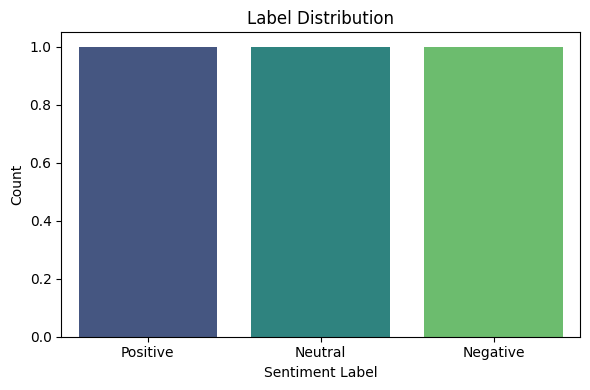

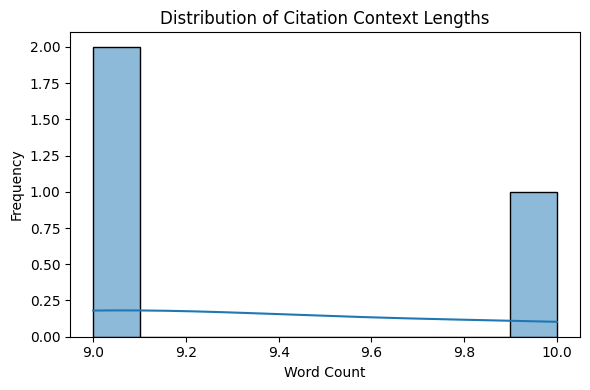

count     3.000000
mean      9.333333
std       0.577350
min       9.000000
25%       9.000000
50%       9.000000
75%       9.500000
max      10.000000
Name: text_len, dtype: float64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


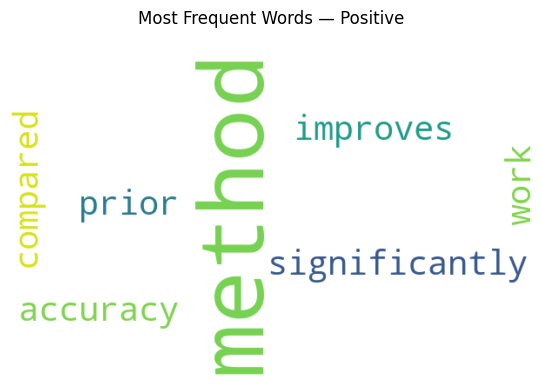

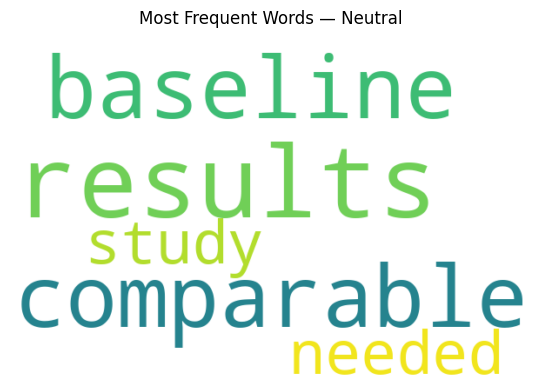

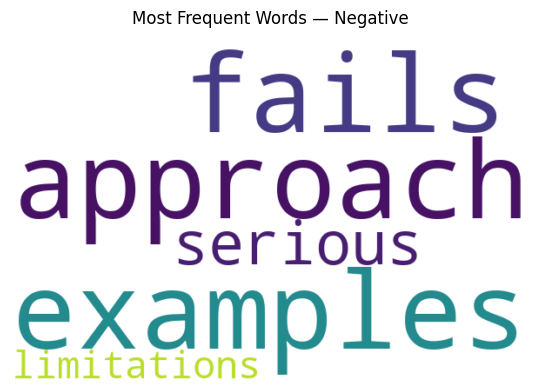


Top words for Positive:


,Word,Frequency
0,method,1
1,significantly,1
2,improves,1
3,accuracy,1
4,compared,1
5,prior,1
6,work,1



Top words for Neutral:


,Word,Frequency
0,results,1
1,comparable,1
2,baseline,1
3,study,1
4,needed,1



Top words for Negative:


,Word,Frequency
0,approach,1
1,fails,1
2,examples,1
3,serious,1
4,limitations,1


✅ Quick EDA Summary
Total records: 3
Label balance:
label
Positive    1
Neutral     1
Negative    1
Name: count, dtype: int64

Average words per citation: 9.33

EDA complete! Figures saved in reports/figures/.


In [ ]:
import sys
import os

# Go up one directory from the notebook folder to the project root
sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import preprocess_dataframe
print("✅ Import successful!")

#cell 1 (imports + setup)
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import Counter
from wordcloud import WordCloud
import os

# Download tokenizer data once (for first run)
nltk.download('punkt')

# Display plots inline
%matplotlib inline

# Paths
DATA_PATH = "../data/mldataset_sample.json"  # replace with ../data/mldataset.json when real data available
os.makedirs("../reports/figures", exist_ok=True)

#cell 2 (load data and preview)
# Load dataset
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("✅ Dataset loaded successfully!")
print(df.head())
print("\nDataset shape:", df.shape)

#cell 3(Check Data Integrity)
print("Columns:", df.columns.tolist())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nUnique labels:", df["label"].unique())

#cell 4 (Label Distribution)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", order=["Positive", "Neutral", "Negative"], palette="viridis")
plt.title("Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/label_distribution.png")
plt.show()

#cell 5 (Text Length Analysis )
df["text_len"] = df["citation_context"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df["text_len"], bins=10, kde=True)
plt.title("Distribution of Citation Context Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/figures/text_length_distribution.png")
plt.show()

print(df["text_len"].describe())

#cell 6 (Word Frequency & wordclouds)
from nltk.tokenize import word_tokenize
import string

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in nltk.corpus.stopwords.words('english')]
    return tokens

nltk.download('stopwords')

# Generate per-label tokens
tokens_by_label = {}
for lbl in df["label"].unique():
    all_tokens = []
    for txt in df.loc[df["label"] == lbl, "citation_context"]:
        all_tokens.extend(preprocess_text(txt))
    tokens_by_label[lbl] = all_tokens

# Wordcloud for each label
for lbl, toks in tokens_by_label.items():
    if len(toks) == 0:
        continue
    plt.figure(figsize=(6,4))
    text_joined = " ".join(toks)
    wc = WordCloud(width=600, height=400, background_color="white").generate(text_joined)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Most Frequent Words — {lbl}")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/wordcloud_{lbl.lower()}.png")
    plt.show()

    #cell 7 (Top Words Table)
def get_top_words(tokens, n=10):
    counts = Counter(tokens)
    return pd.DataFrame(counts.most_common(n), columns=["Word", "Frequency"])

for lbl, toks in tokens_by_label.items():
    print(f"\nTop words for {lbl}:")
    display(get_top_words(toks))

    #cell 8 (Summary Findings)
print("✅ Quick EDA Summary")
print(f"Total records: {len(df)}")
print("Label balance:")
print(df['label'].value_counts())
print(f"\nAverage words per citation: {df['text_len'].mean():.2f}")
print("\nEDA complete! Figures saved in reports/figures/.")


In [9]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
import nltk
nltk.download('all')


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       tagge

True

In [13]:

import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\johnn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [1]:
from src.preprocessing import preprocess_dataframe
print("✅ Import successful!")


✅ Import successful!
